Interpolated missing values in od-sensors-4.od-720_B01 using od-sensors-5.od-720_B02, differential: -0.369696
No peaks detected in od-sensors-1.od-720_A01
Detected bumps/drops in od-sensors-1.od-720_A01:
  Time: 14.33 hr, Differential: 0.338375
No peaks detected in od-sensors-2.od-720_A02
Detected bumps/drops in od-sensors-2.od-720_A02:
  Time: 14.33 hr, Differential: 0.178690
  Time: 47.08 hr, Differential: -0.068572
Detected peaks in od-sensors-3.od-720_A03 at times: [np.float64(1.08), np.float64(1.17), np.float64(2.75), np.float64(2.83), np.float64(5.17), np.float64(5.25), np.float64(5.58), np.float64(5.67), np.float64(5.75), np.float64(6.0), np.float64(6.08), np.float64(6.92), np.float64(7.0), np.float64(8.42), np.float64(8.5), np.float64(8.58), np.float64(10.33), np.float64(10.42), np.float64(11.08), np.float64(11.17), np.float64(12.17), np.float64(12.25), np.float64(12.33), np.float64(12.42), np.float64(12.5)]
No bumps/drops detected in od-sensors-3.od-720_A03
Detected peaks in o

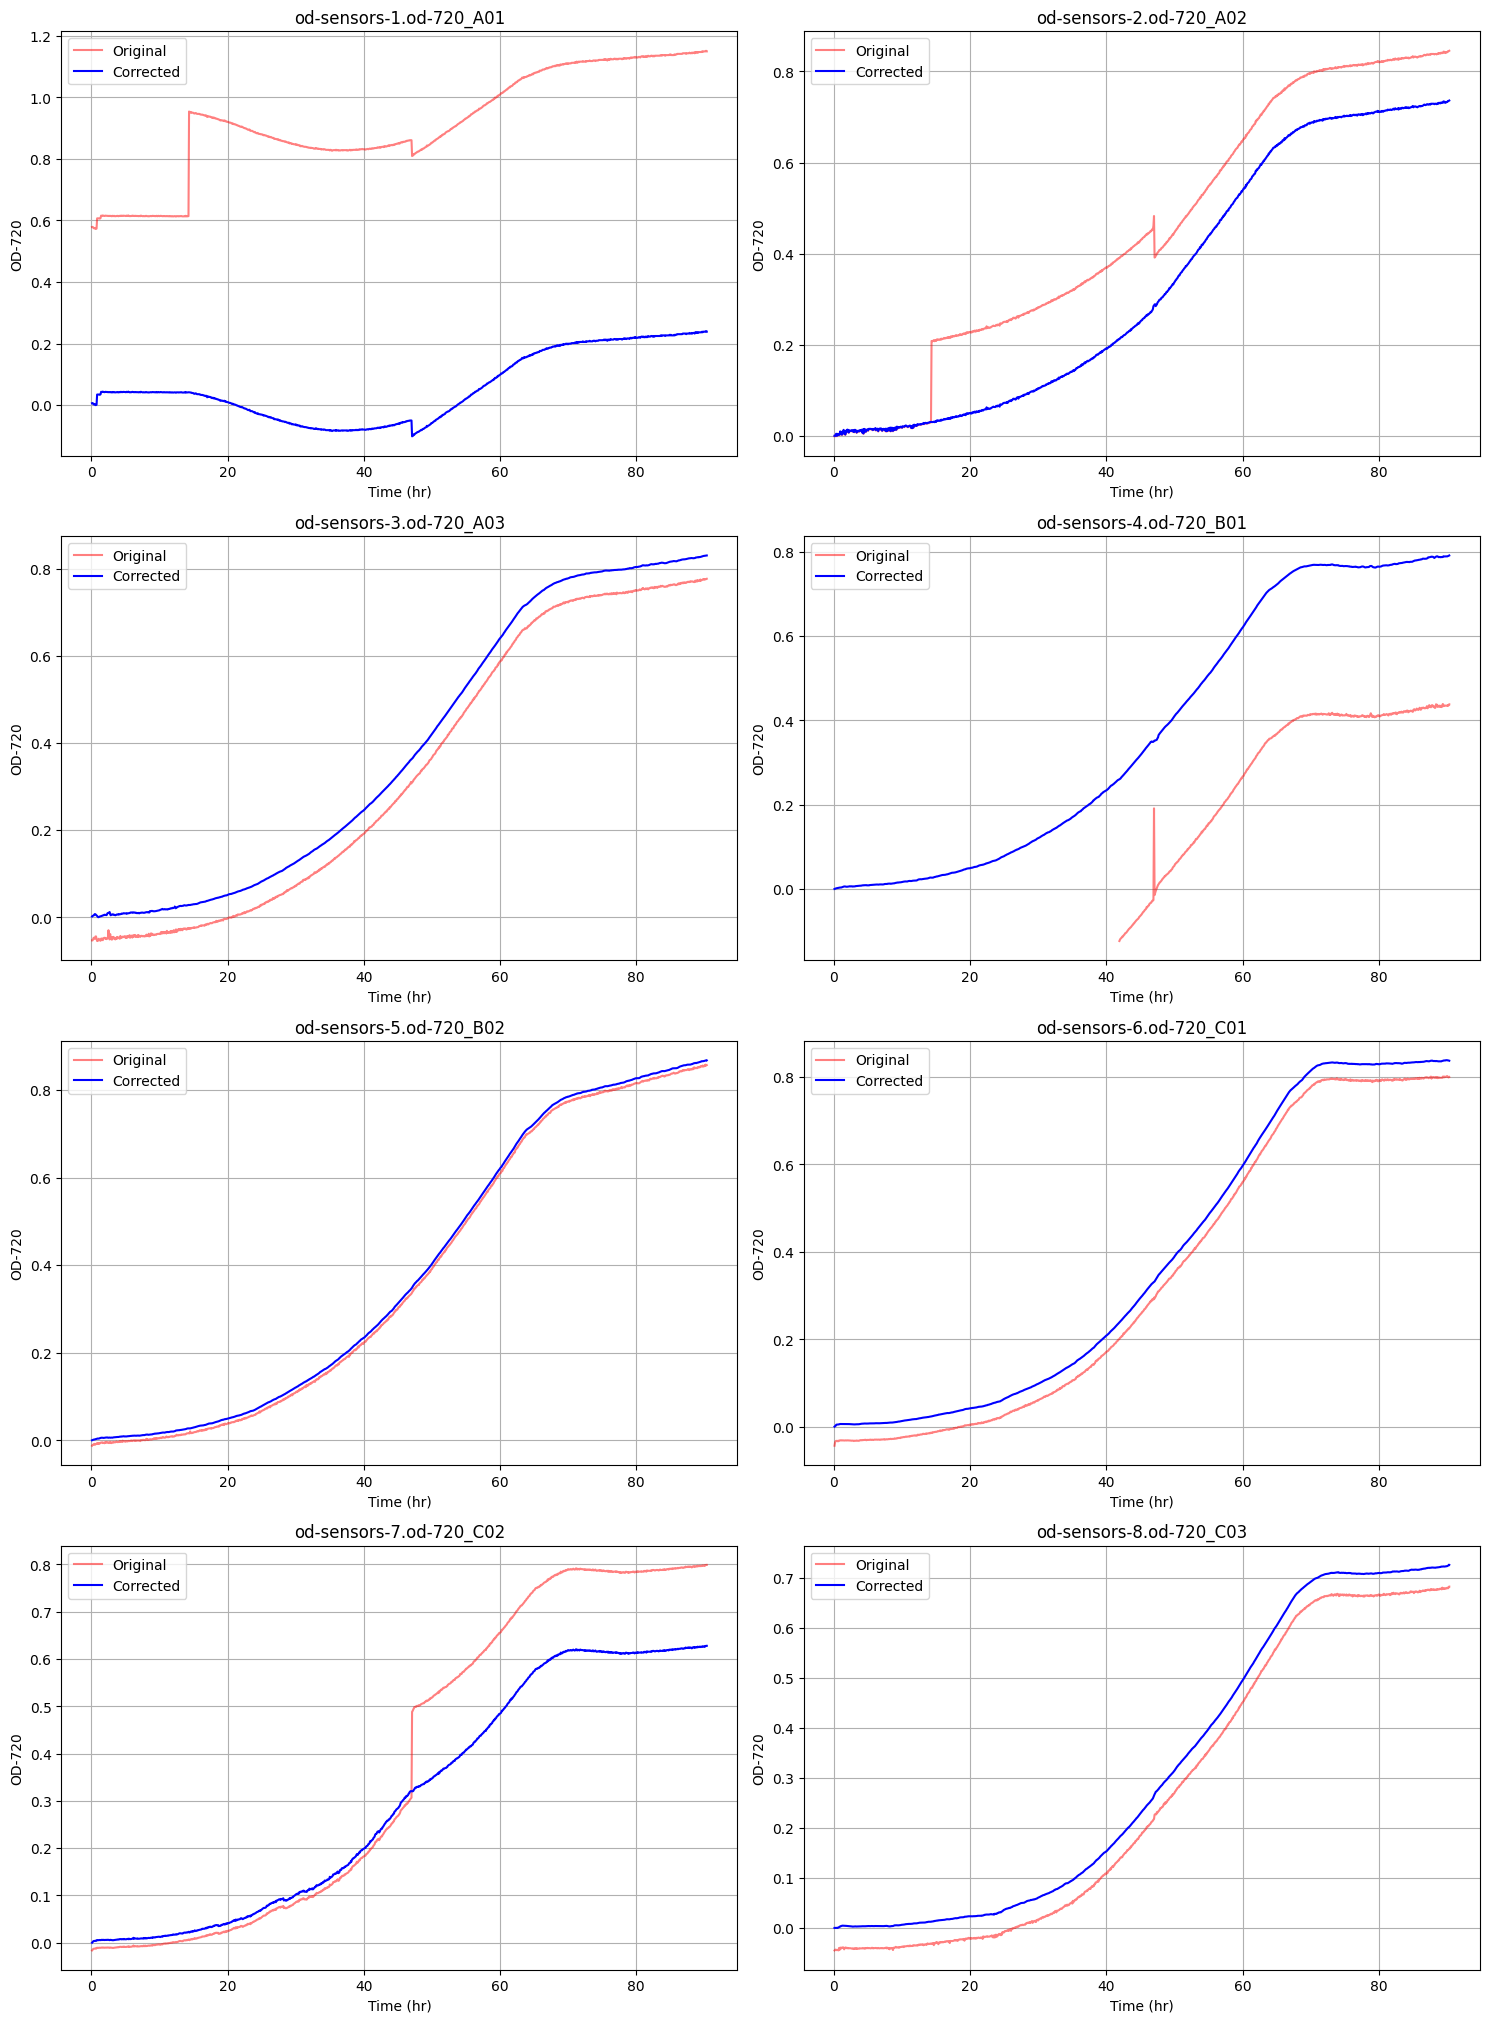

Corrected bump, generalized peak, and baseline corrected data saved to 'corrected_bump_generalized_peak_baseline_corrected_0417TOP_720.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Processing 1: Load the original CSV data, clean-up bumps
raw_datafile = "0417TOP"
data = pd.read_csv(raw_datafile+'.csv')

# Clean up column names by stripping whitespace
data.columns = data.columns.str.strip()

# Convert sensor columns to numeric, coercing errors to NaN
sensor_columns = [col for col in data.columns if 'od-sensors' in col]
for col in sensor_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Step 1: Generalized interpolation for missing values
def extract_replicate_info(column_name):
    match = re.search(r'od-sensors-\d+\.od-680_([A-Z])(\d{2})', column_name)
    if match:
        return match.group(1), match.group(2)
    return None, None

replicate_groups = {}
for col in sensor_columns:
    sample_type, rep_num = extract_replicate_info(col)
    if sample_type:
        if sample_type not in replicate_groups:
            replicate_groups[sample_type] = []
        replicate_groups[sample_type].append(col)

def has_missing_in_first_two_hours(df, column, time_limit=2):
    mask = df['time (hr)'] <= time_limit
    return df.loc[mask, column].isna().any()

def calculate_differential(df, col1, col2, start_time, time_limit=2):
    mask = (df['time (hr)'] >= start_time) & (df['time (hr)'] <= start_time + time_limit) & df[col1].notna() & df[col2].notna()
    if not mask.any():
        return 0
    differential = (df.loc[mask, col1] - df.loc[mask, col2]).mean()
    return differential

def interpolate_missing(df, target_col, ref_col, differential):
    result = df[target_col].copy()
    mask_missing = result.isna()
    result[mask_missing] = df.loc[mask_missing, ref_col] + differential
    for idx in df[mask_missing].index:
        nearby_indices = [i for i in [idx-1, idx, idx+1] if i in df.index and not np.isnan(df.loc[i, ref_col])]
        if nearby_indices:
            nearby_values = df.loc[nearby_indices, ref_col]
            std_dev = nearby_values.std() if len(nearby_values) > 1 else 0.01
            variation = np.random.normal(0, std_dev / 2)
            result[idx] += variation
    return result

corrected_data = data.copy()
missing_columns = [col for col in sensor_columns if has_missing_in_first_two_hours(data, col)]
for target_col in missing_columns:
    sample_type, _ = extract_replicate_info(target_col)
    candidate_replicates = [col for col in replicate_groups.get(sample_type, []) if col != target_col and not has_missing_in_first_two_hours(data, col)]
    if candidate_replicates:
        ref_col = candidate_replicates[0]
        first_valid_time = data['time (hr)'][data[target_col].notna()].min()
        if not np.isnan(first_valid_time):
            differential = calculate_differential(data, target_col, ref_col, first_valid_time)
            corrected_data[target_col] = interpolate_missing(data, target_col, ref_col, differential)
            print(f"Interpolated missing values in {target_col} using {ref_col}, differential: {differential:.6f}")

# Step 2: Detect and remove peaks (calibrated to detect peak in XXX)
def detect_peaks(df, column, benchmark_column='od-sensors-2.od-680_A02', threshold_factor=2.5):
    """
    Detect transient peaks (up-and-down or down-and-up over two points).
    Calibrated to detect peak in od-sensors-2 at 40-50 hr.
    """
    first_diff = df[column].diff()
    second_diff = first_diff.diff()
    ref_first_diff = df[benchmark_column].diff()
    mask_window = (df['time (hr)'] >= 40) & (df['time (hr)'] <= 50)
    ref_std_diff = ref_first_diff[mask_window].abs().std()
    threshold = threshold_factor * ref_std_diff

    peak_indices = []
    for idx in range(2, len(df) - 2):
        if (abs(first_diff.iloc[idx]) > threshold and abs(first_diff.iloc[idx + 1]) > threshold and
            np.sign(first_diff.iloc[idx]) != np.sign(first_diff.iloc[idx + 1])):
            baseline_before = df[column].iloc[max(0, idx - 2):idx].mean()
            baseline_after = df[column].iloc[idx + 2:min(len(df), idx + 4)].mean()
            current_val = df[column].iloc[idx]
            next_val = df[column].iloc[idx + 1]
            peak_height = max(abs(current_val - baseline_before), abs(next_val - baseline_before))
            if (abs(baseline_after - baseline_before) < threshold / 2 and
                peak_height > threshold):
                if column == benchmark_column:
                    if abs(baseline_after - baseline_before) > threshold / 4:
                        continue
                peak_indices.extend([idx, idx + 1])
    return sorted(list(set(peak_indices)))

# Step 3: Refill peaks with moving average
def refill_peaks(df, column, peak_indices, window_size=5):
    """
    Replace peak values (set to NaN) with moving average of nearby points.
    """
    result = df[column].copy()
    result[peak_indices] = np.nan
    result = result.rolling(window=window_size, center=True, min_periods=1).mean()
    return result

# Step 4: Detect and correct bumps/drops (restored persistence check)
def detect_bumps_drops(df, column, time_windows, window_size=4, threshold_factor=5):
    """
    Detect sustained baseline shifts in specified time windows.
    """
    differences = df[column].diff().abs()
    std_diff = differences.std()
    threshold = threshold_factor * std_diff
    bumps_drops = []

    for start, end in time_windows:
        mask = (df['time (hr)'] >= start) & (df['time (hr)'] <= end)
        window_data = df[mask]
        if window_data.empty:
            continue
        large_diff_indices = window_data.index[window_data[column].diff().abs() > threshold]
        for idx in large_diff_indices:
            if idx == 0 or idx >= len(df) - 1:
                continue
            before_indices = [i for i in range(max(0, idx - window_size), idx) if i in df.index]
            after_indices = [i for i in range(idx, min(len(df), idx + window_size)) if i in df.index]
            if before_indices and after_indices:
                before_avg = df.loc[before_indices, column].mean()
                after_avg = df.loc[after_indices, column].mean()
                differential = after_avg - before_avg
                if abs(differential) > threshold:
                    subsequent_indices = [i for i in range(idx + 1, min(len(df), idx + window_size + 1)) if i in df.index]
                    if subsequent_indices:
                        subsequent_avg = df.loc[subsequent_indices, column].mean()
                        if abs(subsequent_avg - after_avg) < threshold / 2:
                            bumps_drops.append((df.loc[idx, 'time (hr)'], differential))

    return bumps_drops

def correct_bumps_drops(df, column, bumps_drops, window_size=4):
    """
    Correct bumps/drops by subtracting differentials and smoothing transitions.
    """
    result = df[column].copy()
    for time, differential in bumps_drops:
        idx = df.index[df['time (hr)'] >= time].min()
        if idx is None:
            continue
        result[idx:] -= differential
        smooth_indices = [i for i in range(max(0, idx - window_size), min(len(df), idx + window_size + 1)) if i in df.index]
        if smooth_indices:
            window_data = result[smooth_indices].rolling(window=window_size, min_periods=1, center=True).mean()
            result[smooth_indices] = window_data

    return result

# Step 5: Baseline correction
def correct_baseline(df, column, time_limit=2):
    """
    Subtract minimum value in first two hours for baseline correction.
    """
    mask = df['time (hr)'] <= time_limit
    min_value = df.loc[mask, column].min()
    if np.isnan(min_value):
        return df[column]
    return df[column] - min_value

# Process all sensor columns: Manually add noticiable errorneous windows
time_windows = [(10,20),(40,50)]

for col in sensor_columns:
    # Step 2: Detect and remove peaks
    peak_indices = detect_peaks(corrected_data, col)
    if peak_indices:
        print(f"Detected peaks in {col} at times: {[round(corrected_data['time (hr)'].iloc[i], 2) for i in peak_indices]}")
        # Step 3: Refill peaks
        corrected_data[col] = refill_peaks(corrected_data, col, peak_indices)
    else:
        print(f"No peaks detected in {col}")

    # Step 4: Detect and correct bumps/drops
    bumps_drops = detect_bumps_drops(corrected_data, col, time_windows)
    if bumps_drops:
        print(f"Detected bumps/drops in {col}:")
        for time, diff in bumps_drops:
            print(f"  Time: {time:.2f} hr, Differential: {diff:.6f}")
        corrected_data[col] = correct_bumps_drops(corrected_data, col, bumps_drops)
    else:
        print(f"No bumps/drops detected in {col}")

    # Step 5: Apply baseline correction
    corrected_data[col] = correct_baseline(corrected_data, col)

# Plot original vs corrected data
plt.figure(figsize=(15, 30))
for i, col in enumerate(sensor_columns, 1):
    plt.subplot(6, 2, i)
    plt.plot(data['time (hr)'], data[col], alpha=0.5, label='Original', color='red')
    plt.plot(corrected_data['time (hr)'], corrected_data[col], label='Corrected', color='blue')
    plt.xlabel('Time (hr)')
    plt.ylabel('OD-720')
    plt.title(f'{col}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

# Save corrected data to a new CSV
corrected_data.to_csv('corrected_bump_generalized_peak_baseline_corrected_'+raw_datafile+'.csv', index=False)
print("Corrected bump, generalized peak, and baseline corrected data saved to 'corrected_bump_generalized_peak_baseline_corrected_"+raw_datafile+".csv'")

Columns after loading data:
Index(['time (hr)', 'od-sensors-1.od-720_A01', 'od-sensors-2.od-720_A02',
       'od-sensors-3.od-720_A03', 'od-sensors-4.od-720_B01',
       'od-sensors-5.od-720_B02', 'od-sensors-6.od-720_C01',
       'od-sensors-7.od-720_C02', 'od-sensors-8.od-720_C03'],
      dtype='object')


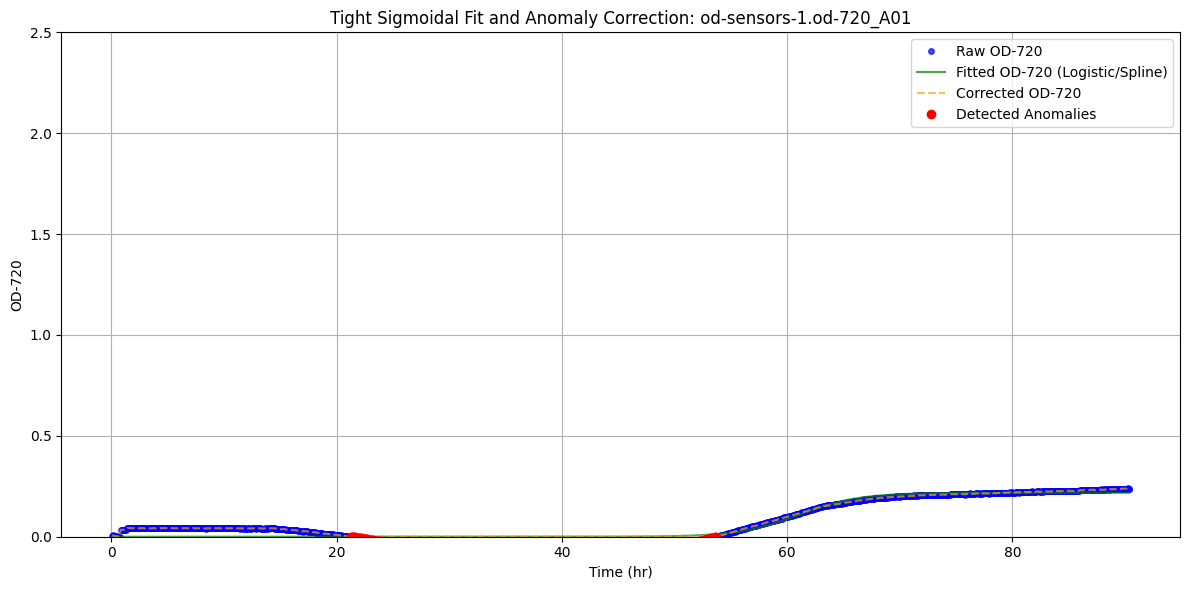

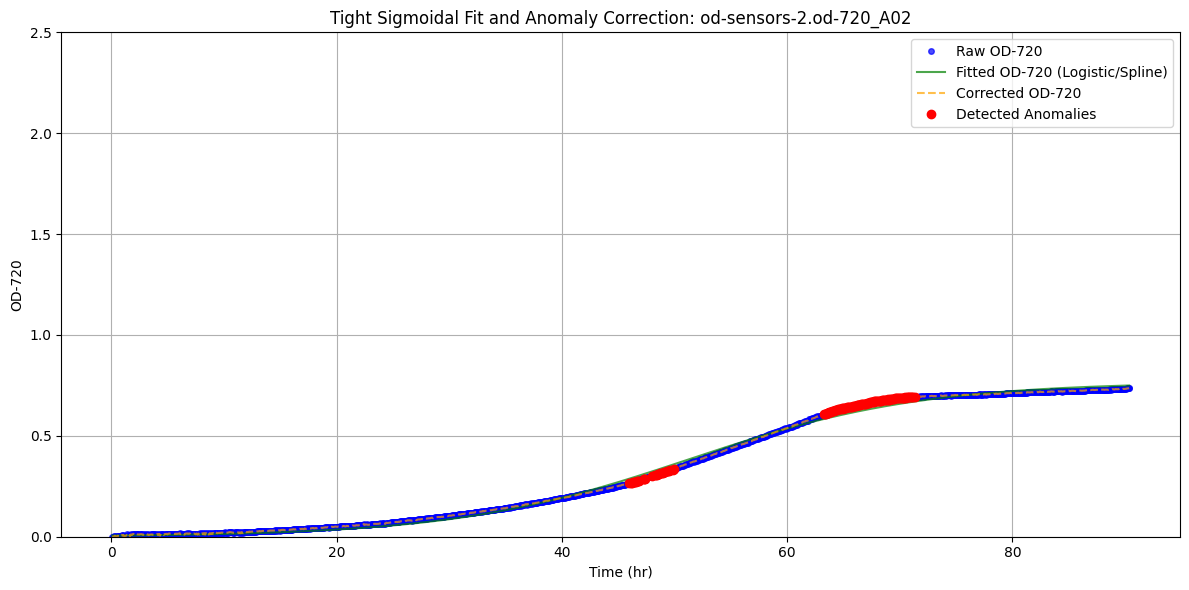

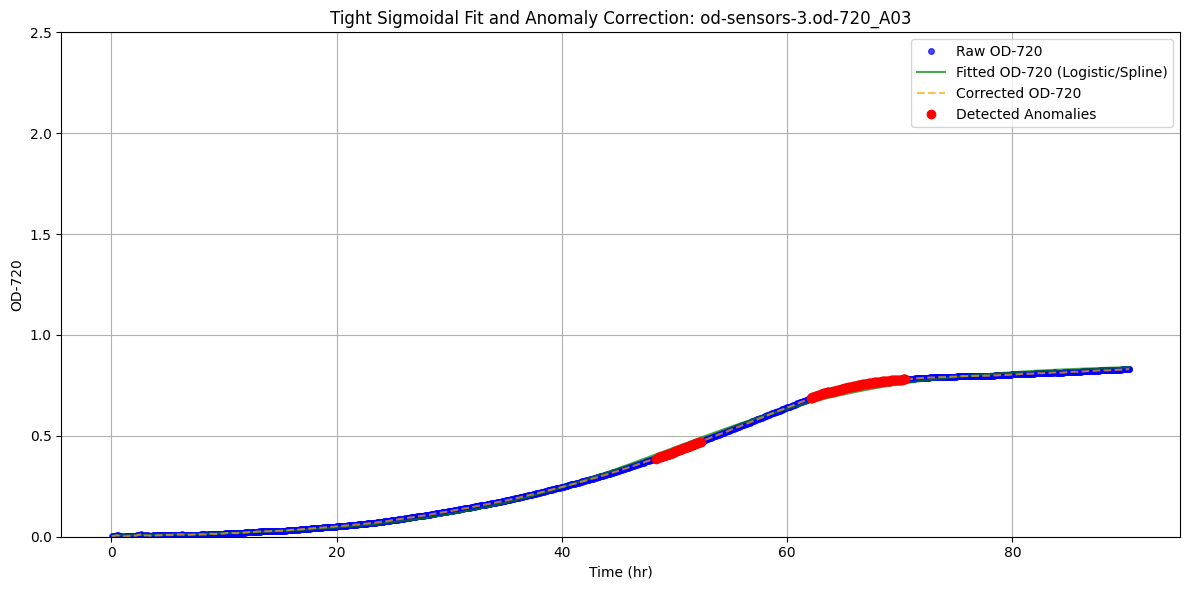

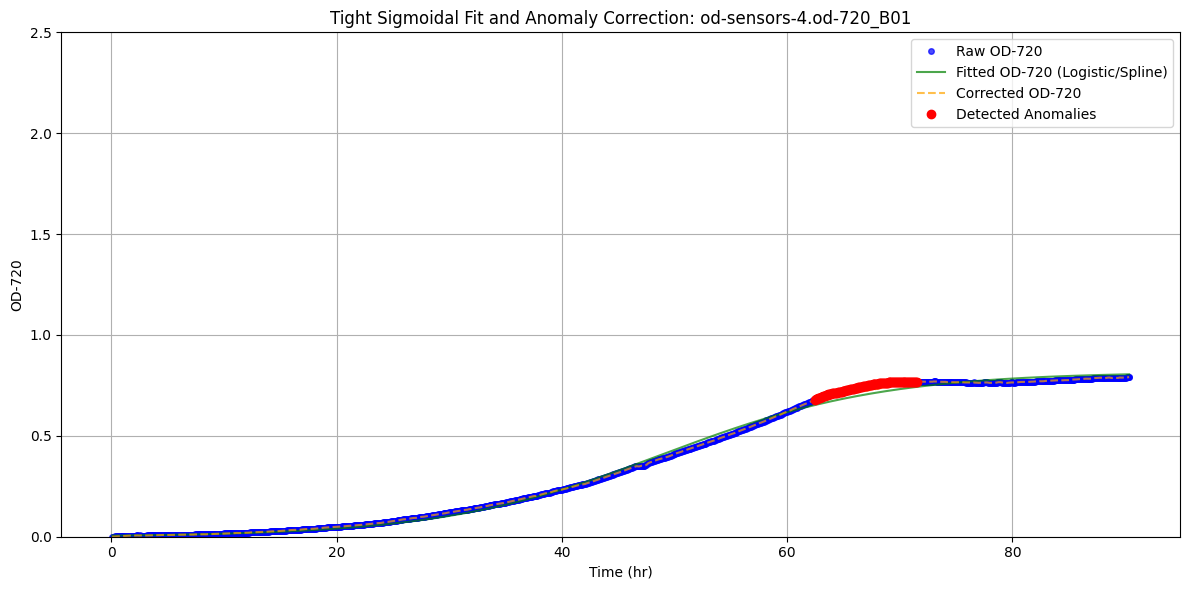

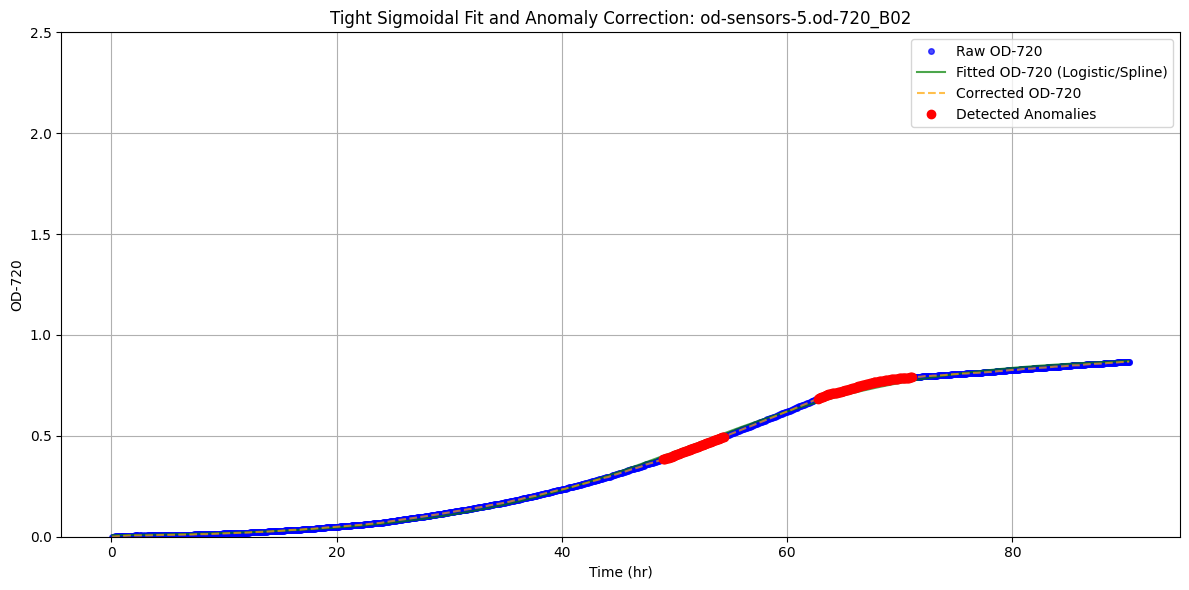

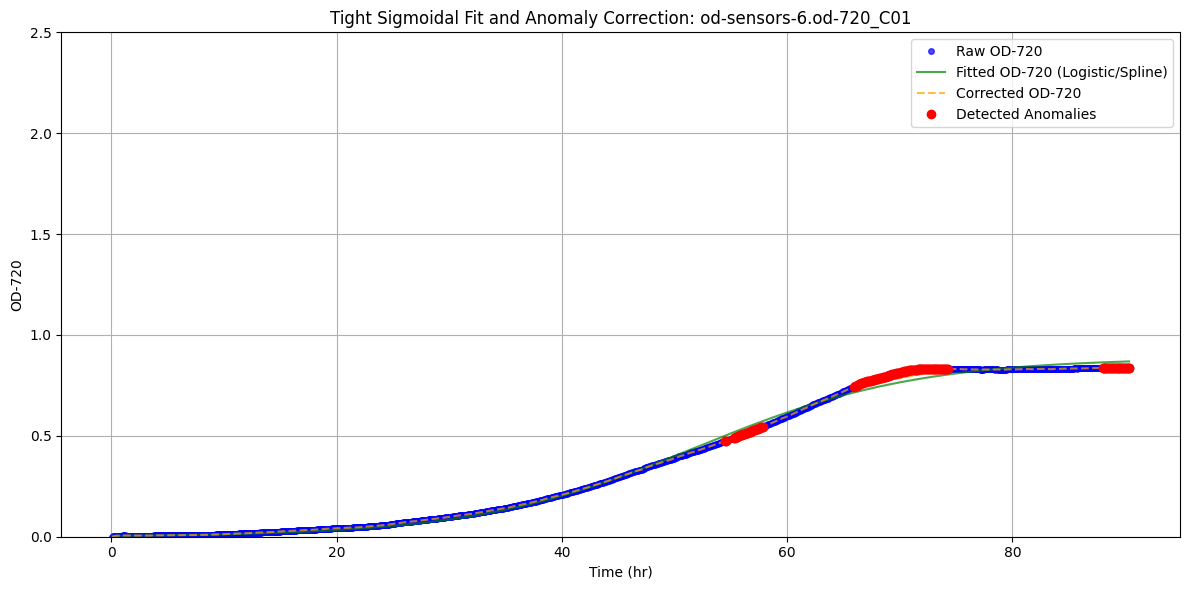

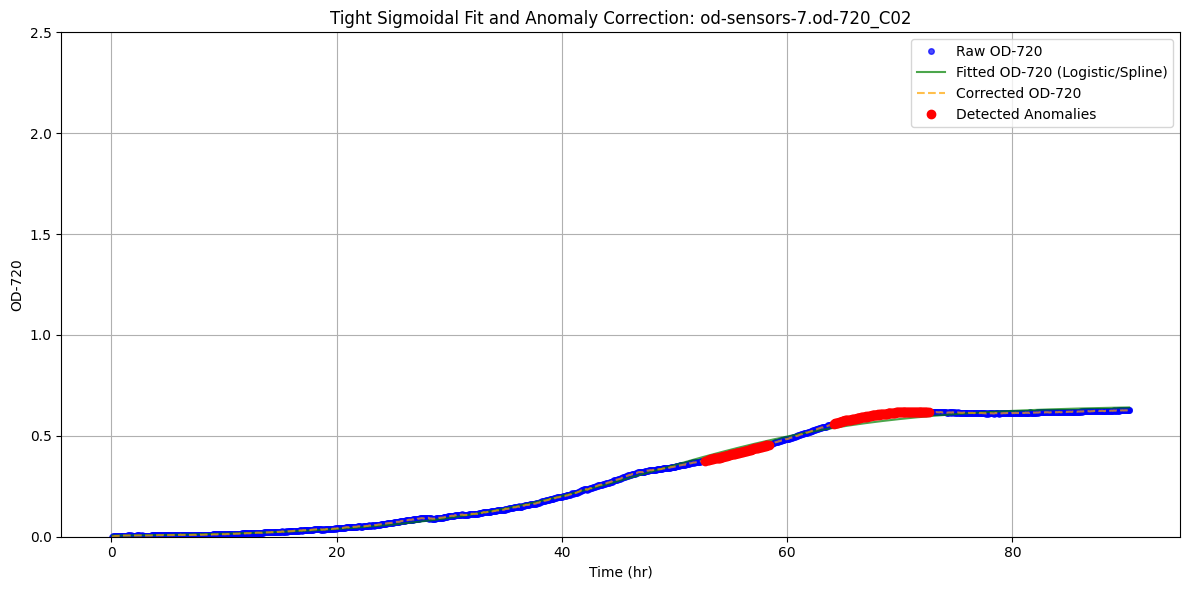

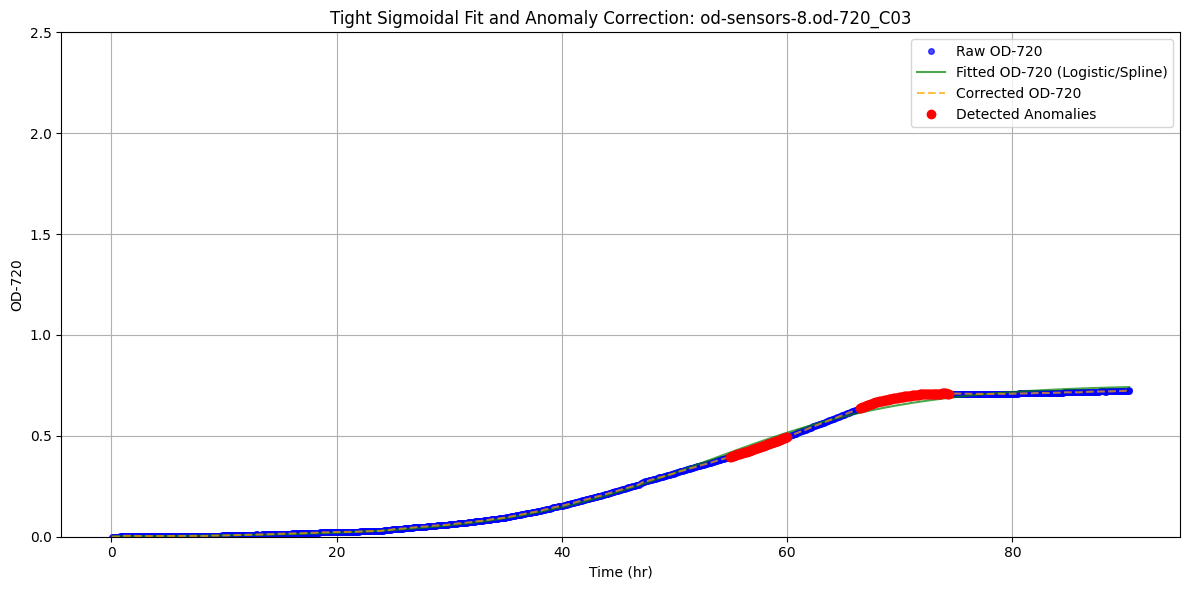

Corrected OD-680 data saved to 'corrected_growth_curve_'0417TOP_720.csv'
Anomaly report saved to 'anomaly_report_0417TOP_720.csv'
Anomaly corrected in od-sensors-1.od-720_A01 at t=21.25h:
  Original: -0.0001, Corrected to: 0.0000, Residual: -0.0001
Anomaly corrected in od-sensors-1.od-720_A01 at t=21.33h:
  Original: -0.0013, Corrected to: 0.0000, Residual: -0.0013
Anomaly corrected in od-sensors-1.od-720_A01 at t=21.42h:
  Original: -0.0013, Corrected to: 0.0000, Residual: -0.0013
Anomaly corrected in od-sensors-1.od-720_A01 at t=21.50h:
  Original: -0.0025, Corrected to: 0.0000, Residual: -0.0025
Anomaly corrected in od-sensors-1.od-720_A01 at t=21.58h:
  Original: -0.0037, Corrected to: 0.0000, Residual: -0.0037


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline

# Processing 2: Inspecting bump_corrected data for sigmoidal and outlier-free correction2 data for analysis
# Load corrected OD data
# The error was likely due to the incorrect separator. Removing sep='\t'.
raw_datafile = "0417TOP"
data = pd.read_csv('corrected_bump_generalized_peak_baseline_corrected_'+raw_datafile+'.csv', na_values=[''])
data.columns = data.columns.str.strip()  # Clean column names

# Display the column names to verify the data loaded correctly
print("Columns after loading data:")
print(data.columns)

# Identify sensor columns
sensor_columns = [col for col in data.columns if 'od-sensors' in col]

# Define logistic function for sigmoidal fit
def logistic(t, L, k, t0):
    """
    Logistic function: OD(t) = L / (1 + exp(-k * (t - t0)))
    Parameters:
    - L: Carrying capacity (max OD)
    - k: Growth rate
    - t0: Inflection point
    """
    return L / (1 + np.exp(-k * (t - t0)))

# Fit and correct data with tight sigmoidal fit
def fit_and_correct(df, column, threshold_factor=1.5):
    """
    Fit tight sigmoidal curve, remove anomalies, and fill with average movement.
    Parameters:
    - df: DataFrame with OD-720 data
    - column: Column name to process
    - threshold_factor: Standard deviations for anomaly detection
    Returns:
    - corrected_values: Series with filled and corrected values
    - fitted_values: Series with fitted values
    - anomalies: List of (index, time, original_value, fitted_value, residual)
    """
    time = df['time (hr)'].values
    values = df[column].values
    non_nan_mask = ~np.isnan(values)
    time_non_nan = time[non_nan_mask]
    values_non_nan = values[non_nan_mask]

    if len(time_non_nan) < 10:
        print(f"Warning: Too few non-NaN points in {column} for fitting")
        return pd.Series(values, index=df.index), pd.Series(values, index=df.index), []

    # Try tight logistic fit
    try:
        p0 = [max(values_non_nan), 0.1, time_non_nan[len(time_non_nan)//2]]  # Tighter initial guess
        bounds = ([0, 0, min(time_non_nan)], [2.5, 1.0, max(time_non_nan)])  # Tighter k bound
        popt, _ = curve_fit(logistic, time_non_nan, values_non_nan, p0=p0, bounds=bounds, maxfev=20000)
        L, k, t0 = popt
        fitted_values = logistic(time, L, k, t0)
    except RuntimeError:
        print(f"Logistic fit failed for {column}, falling back to tight spline")
        # Tight spline with minimal smoothing
        spline = UnivariateSpline(time_non_nan, values_non_nan, k=3, s=0.01)
        fitted_values = spline(time)

    # Ensure non-negative fitted values
    fitted_values = np.maximum(fitted_values, 0)

    # Detect anomalies (residuals > threshold_factor * std)
    residuals = values - fitted_values
    non_nan_residuals = residuals[non_nan_mask]
    std_residual = np.std(non_nan_residuals) if len(non_nan_residuals) > 0 else 0
    threshold = threshold_factor * std_residual
    anomalies = []
    corrected_values = values.copy()

    for i in range(len(values)):
        if not np.isnan(values[i]):
            if abs(residuals[i]) > threshold or values[i] < 0:  # Negative values are anomalies
                anomalies.append((i, time[i], values[i], fitted_values[i], residuals[i]))
                corrected_values[i] = np.nan  # Remove anomaly

    # Fill gaps (including anomaly locations) with average movement
    corrected_values_filled = corrected_values.copy()
    for i in range(len(corrected_values)):
        if np.isnan(corrected_values[i]):
            # Find the nearest non-NaN points before and after
            before_idx = i - 1
            while before_idx >= 0 and np.isnan(corrected_values[before_idx]):
                before_idx -= 1
            after_idx = i + 1
            while after_idx < len(corrected_values) and np.isnan(corrected_values[after_idx]):
                after_idx += 1

            if before_idx >= 0 and after_idx < len(corrected_values):
                t_before, v_before = time[before_idx], corrected_values[before_idx]
                t_after, v_after = time[after_idx], corrected_values[after_idx]
                slope = (v_after - v_before) / (t_after - t_before) if t_after != t_before else 0
                corrected_values_filled[i] = v_before + slope * (time[i] - t_before)

    # Ensure non-negative filled values
    corrected_values_filled = np.maximum(corrected_values_filled, 0)

    return pd.Series(corrected_values_filled, index=df.index), pd.Series(fitted_values, index=df.index), anomalies

# Process each sensor column
corrected_data = data.copy()
anomaly_log = []

for col in sensor_columns:
    # Fit and correct with tight sigmoidal fit
    corrected_data[col], fitted_values, anomalies = fit_and_correct(data, col)
    anomaly_log.extend([(col, idx, t, orig, fit, resid) for idx, t, orig, fit, resid in anomalies])

    # Plot raw, fitted, and corrected data
    plt.figure(figsize=(12, 6))
    time = data['time (hr)']

    # Plot raw data (blue dots, gaps for NaN)
    plt.plot(time, data[col], 'bo', label='Raw OD-680', alpha=0.7, markersize=4)
    # Plot fitted data (green line)
    plt.plot(time, fitted_values, 'g-', label='Fitted OD-680 (Logistic/Spline)', alpha=0.7)
    # Plot corrected data (orange dashed line)
    plt.plot(time, corrected_data[col], 'orange', linestyle='--', label='Corrected OD-680', alpha=0.7)
    # Plot anomalies (red markers)
    if anomalies:
        anomaly_times = [t for _, t, _, _, _ in anomalies]
        anomaly_values = [orig for _, _, orig, _, _ in anomalies]
        plt.plot(anomaly_times, anomaly_values, 'ro', label='Detected Anomalies', markersize=6)

    plt.xlabel('Time (hr)')
    plt.ylabel('OD-680')
    plt.title(f'Tight Sigmoidal Fit and Anomaly Correction: {col}')
    plt.ylim(0, 2.5)  # Cover OD-680 range
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'corrected_plot_{col}_tight_'+raw_datafile+'.png')
    plt.show()

# Save corrected data
corrected_data.to_csv('corrected_growth_curve_'+raw_datafile+'.csv', index=False)
print("Corrected data saved to 'corrected_growth_curve_'"+raw_datafile+".csv'")

# Save anomaly report
anomaly_df = pd.DataFrame(anomaly_log, columns=['Column', 'Index', 'Time (hr)', 'Original Value', 'Fitted Value', 'Residual'])
anomaly_df.to_csv('anomaly_report_'+raw_datafile+'.csv', index=False)
print("Anomaly report saved to 'anomaly_report_"+raw_datafile+".csv'")

# Print sample anomalies
sample_anomalies = anomaly_df.head(5)
for _, row in sample_anomalies.iterrows():
    print(f"Anomaly corrected in {row['Column']} at t={row['Time (hr)']:.2f}h:")
    print(f"  Original: {row['Original Value']:.4f}, Corrected to: {row['Fitted Value']:.4f}, Residual: {row['Residual']:.4f}")

Straightened curve data saved to 'straightened_curve_NH4select_2025.csv'
Publication-ready data with standard error saved to 'publication_ready_se_Urea5119_2025.csv'


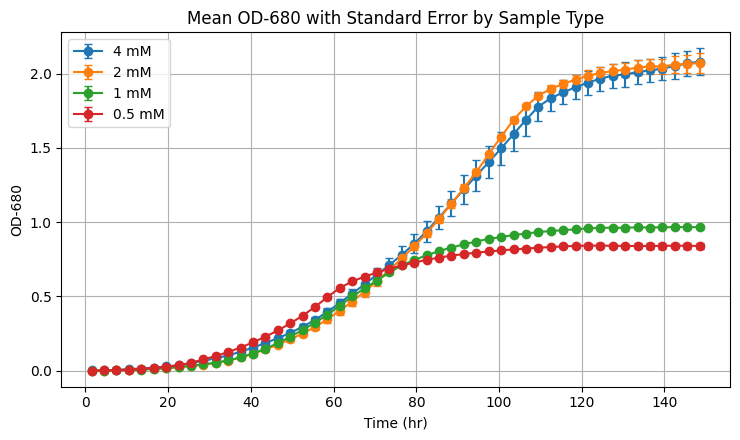

Hourly growth rate data (12 steps, OD threshold) saved to 'growth_rates_hourly_12steps_od_threshold_Urea5119_2025.csv'


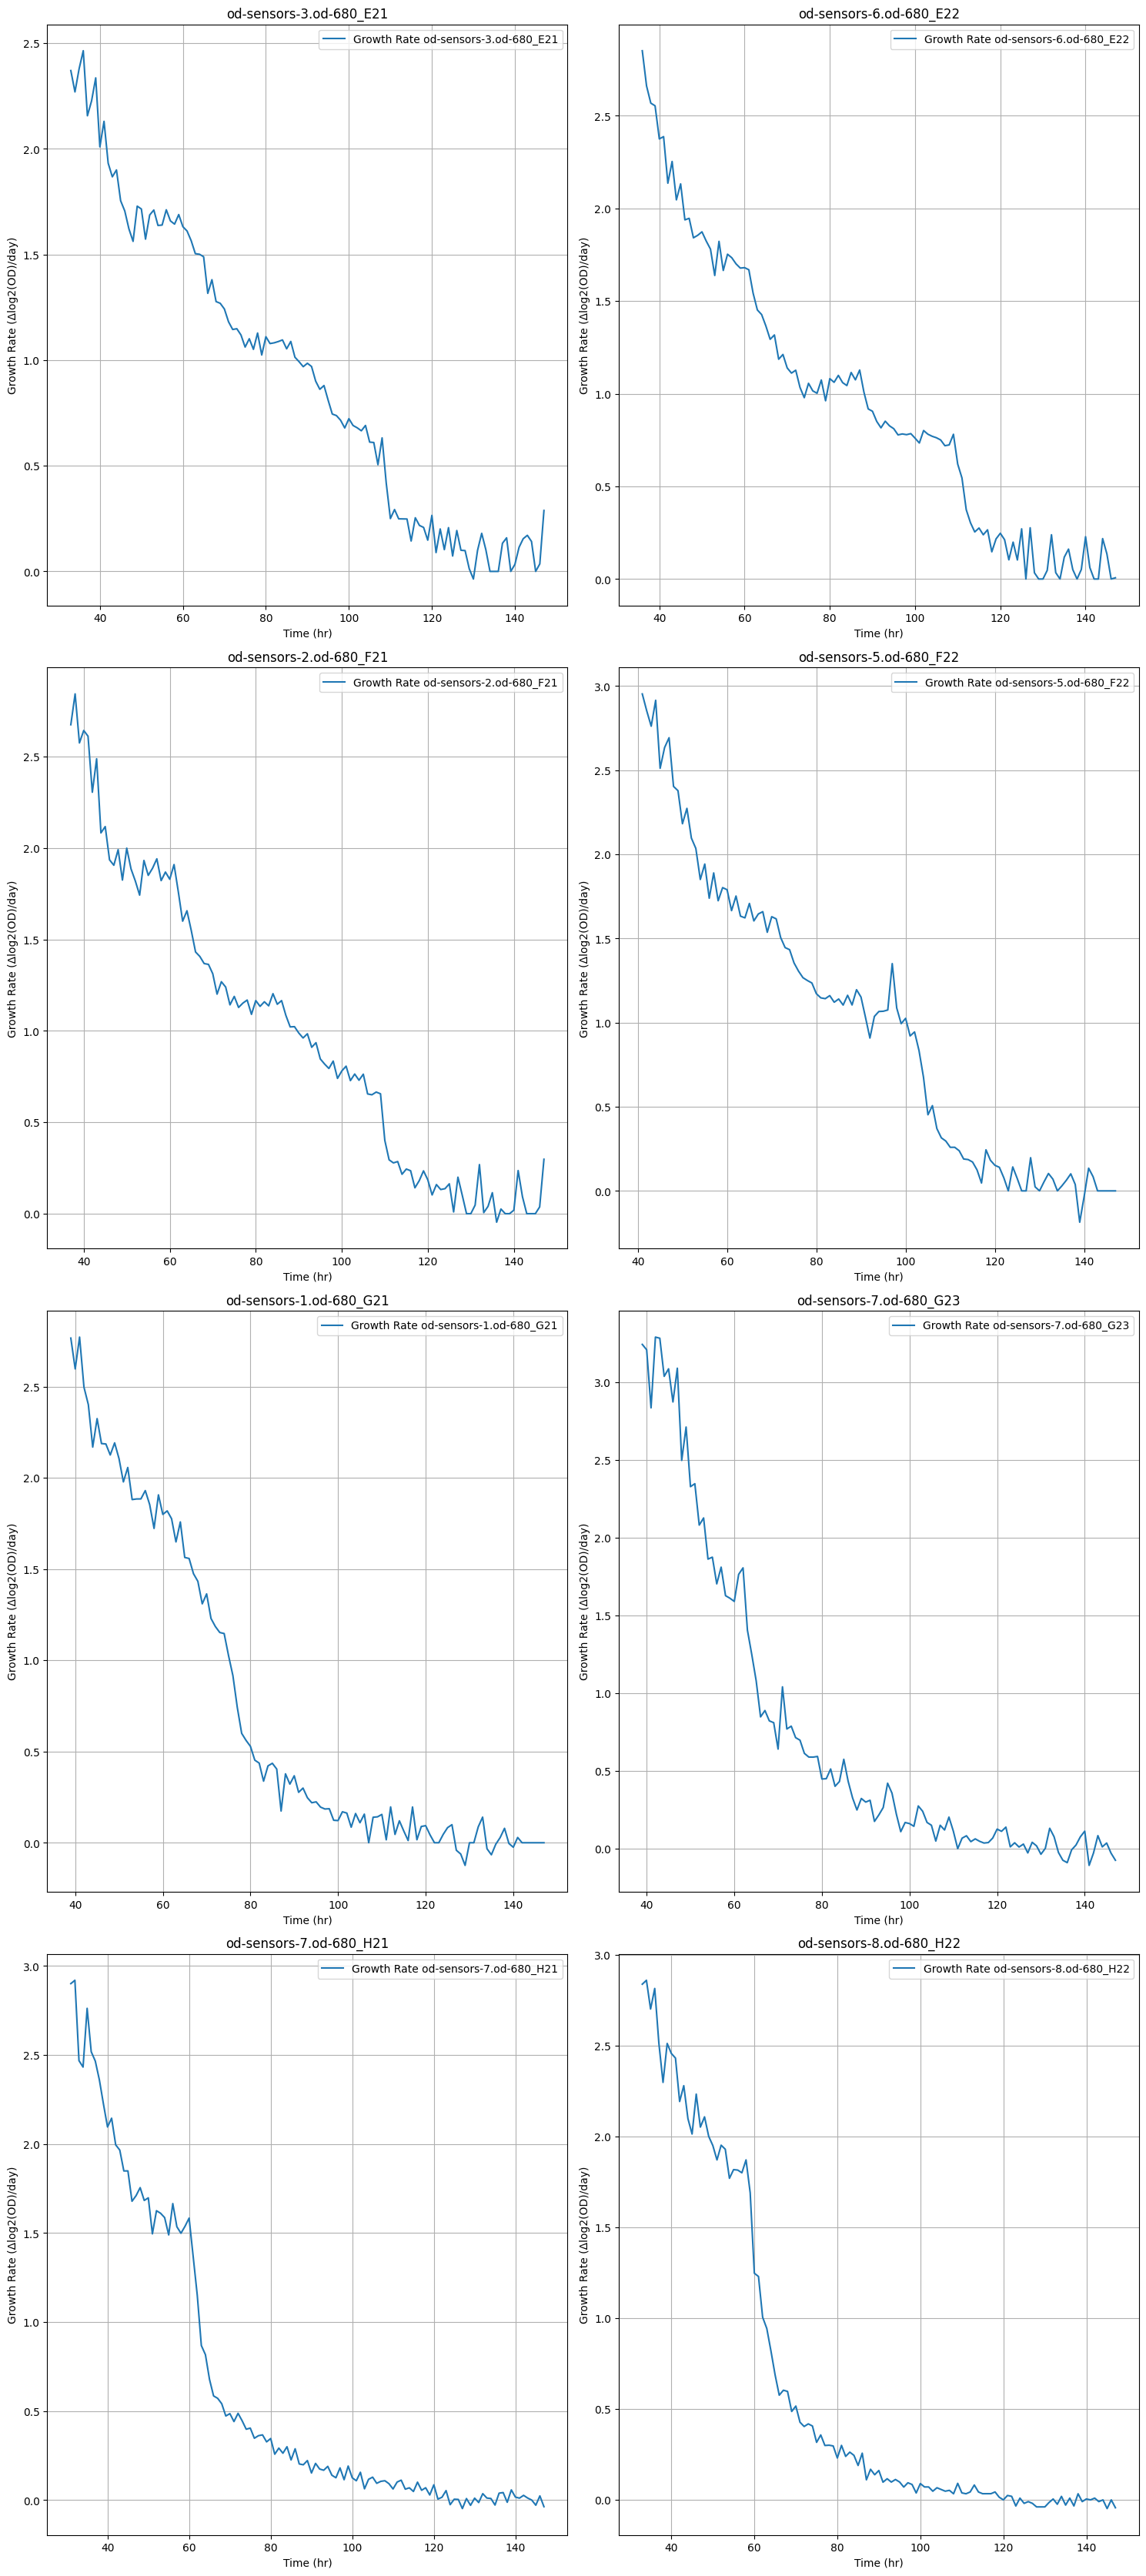

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Analysis 1: Produce Plot with labeling option
# Load the compiled corrected CSV data: GR/day version trial
processed_datafile = "Urea5119select_2025"
data = pd.read_csv("ProcessedCurves"+processed_datafile+".csv")

# Clean up column names by stripping whitespace
data.columns = data.columns.str.strip()

# Identify sensor columns
sensor_columns = [col for col in data.columns if 'od-sensors' in col]

# Step 1: Generate straightened curve (11-point moving average)
def straighten_curve(df, column, window_size=11):
    """
    Smooth the data using a centered moving average with the specified window size.
    """
    return df[column].rolling(window=window_size, center=True, min_periods=1).mean()

straightened_data = data.copy()
for col in sensor_columns:
    straightened_data[col] = straighten_curve(data, col)
straightened_data.to_csv('straightened_curve_'+processed_datafile+'.csv', index=False)
print("Straightened curve data saved to 'straightened_curve_"+processed_datafile+".csv'")

# Step 2: Publication-ready output (mean and standard error every 3 hours)
def extract_replicate_info(column_name):
    match = re.search(r'od-sensors-\d+\.od-680_([A-Z])(\d{02})', column_name)
    if match:
        return match.group(1)
    return None

# Group columns by sample type
sample_groups = {}
for col in sensor_columns:
    sample_type = extract_replicate_info(col)
    if sample_type:
        if sample_type not in sample_groups:
            sample_groups[sample_type] = []
        sample_groups[sample_type].append(col)

# Create time bins every 3 hours
max_time = data['time (hr)'].max()
time_bins = np.arange(0, max_time + 3, 3)
time_bin_centers = (time_bins[:-1] + time_bins[1:]) / 2

# Calculate mean and standard error for each sample type
publication_data = []
for sample_type, cols in sample_groups.items():
    for i in range(len(time_bins) - 1):
        start, end = time_bins[i], time_bins[i + 1]
        mask = (data['time (hr)'] >= start) & (data['time (hr)'] < end)
        window_data = data.loc[mask, cols]
        if not window_data.empty:
            # Compute mean for each replicate in the time bin
            replicate_means = window_data.mean()
            # Calculate mean and standard error of replicate means
            mean_value = replicate_means.mean()
            std_value = replicate_means.std()
            n = replicate_means.count()  # Number of replicates with non-missing data
            se_value = std_value / np.sqrt(n) if n > 0 else np.nan
            publication_data.append({
                'Sample Type': sample_type,
                'Time (hr)': time_bin_centers[i],
                'Mean OD-680': mean_value,
                'Standard Error': se_value
            })

publication_df = pd.DataFrame(publication_data)
publication_df.to_csv('publication_ready_se_'+processed_datafile+'.csv', index=False)
print("Publication-ready data with standard error saved to 'publication_ready_se_"+processed_datafile+".csv'")

# Load the se data for visualization
publication_df = pd.read_csv('publication_ready_se_'+processed_datafile+'.csv')
# Define the desired order and names for sample types
sample_types_ordered = ['4 mM', '2 mM', '1 mM', '0.5 mM']

# Mapping from original sample type (A-Z) to desired names
sample_type_mapping = {
    'E': '4 mM',
    'F': '2 mM',
    'G': '1 mM',
    'H': '0.5 mM'
}

# Map the 'Sample Type' column in the dataframe to the new names
publication_df['Sample Type'] = publication_df['Sample Type'].map(sample_type_mapping)

# Plot publication-ready data with standard error
plt.figure(figsize=(7.5, 4.5))
for sample_type_name in sample_types_ordered:
    sample_data = publication_df[publication_df['Sample Type'] == sample_type_name]
    plt.errorbar(sample_data['Time (hr)'], sample_data['Mean OD-680'], yerr=sample_data['Standard Error'],
                 label=f'{sample_type_name}', capsize=3, marker='o')
plt.xlabel('Time (hr)')
plt.ylabel('OD-680')
plt.title('Mean OD-680 with Standard Error by Sample Type')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('publication_plot_se_'+processed_datafile+'.png')
plt.show()

# Step 3: Growth rate calculation from straightened curve at hourly intervals, 12 steps apart, with OD threshold
def interpolate_od(df, column, target_time):
    """
    Interpolate OD value at the target time using linear interpolation.
    """
    if target_time < df['time (hr)'].min() or target_time > df['time (hr)'].max():
        return np.nan
    before = df[df['time (hr)'] <= target_time].iloc[-1]
    after = df[df['time (hr)'] >= target_time].iloc[0]
    if before['time (hr)'] == after['time (hr)']:
        return before[column] if not np.isnan(before[column]) else np.nan
    weight = (target_time - before['time (hr)']) / (after['time (hr)'] - before['time (hr)'])
    return before[column] + weight * (after[column] - before[column])

def calculate_growth_rate_hourly_12steps(df, column, min_time=2.0, steps=12, od_threshold=0.1):
    """
    Calculate growth rate as ((log2(OD_present) - log2(OD_12_steps_ago)) / delta_hr) * 24 for per day calculations
    at exact hourly intervals after min_time, using the point 12 steps prior (10 hour interval).
    Set to NaN if OD_present < od_threshold.
    """
    max_time = df['time (hr)'].max()
    hourly_times = np.arange(np.ceil(min_time), max_time + 1, 1)
    growth_rates = []
    for t in hourly_times:
        current_od = interpolate_od(df, column, t)
        # Check OD threshold
        if not np.isnan(current_od) and current_od < od_threshold:
            growth_rates.append({'Time (hr)': t, f'Growth Rate {column}': np.nan})
            continue
        # Find the index 12 steps prior to the closest current time point
        current_idx = df[df['time (hr)'] <= t].index[-1] if any(df['time (hr)'] <= t) else None
        if current_idx is None or current_idx - steps < 0:
            growth_rates.append({'Time (hr)': t, f'Growth Rate {column}': np.nan})
            continue
        prev_idx = current_idx - steps
        prev_time = df['time (hr)'].iloc[prev_idx]
        prev_od = df[column].iloc[prev_idx]
        delta_hr = t - prev_time
        if not np.isnan(current_od) and not np.isnan(prev_od) and current_od > 0 and prev_od > 0 and delta_hr > 0:
            growth_rate = ((np.log2(current_od) - np.log2(prev_od)) / delta_hr) * 24
            growth_rates.append({'Time (hr)': t, f'Growth Rate {column}': growth_rate})
        else:
            growth_rates.append({'Time (hr)': t, f'Growth Rate {column}': np.nan})
    return pd.DataFrame(growth_rates)

# Load straightened data for growth rate calculation
straightened_data = pd.read_csv('straightened_curve_'+processed_datafile+'.csv')

# Calculate growth rates for each sensor column
growth_rate_dfs = [calculate_growth_rate_hourly_12steps(straightened_data, col) for col in sensor_columns]
growth_rate_data = growth_rate_dfs[0][['Time (hr)']]
for df in growth_rate_dfs:
    growth_rate_data = growth_rate_data.merge(df, on='Time (hr)', how='outer')
growth_rate_data = growth_rate_data.sort_values('Time (hr)')
growth_rate_data.to_csv('growth_rates_hourly_perDay_od_threshold_'+processed_datafile+'.csv', index=False)
print("Hourly growth rate data (12 steps, OD threshold) saved to 'growth_rates_hourly_12steps_od_threshold_"+processed_datafile+".csv'")

# Load growth rate data for visulaization
#straightened_data = pd.read_csv('straightened_curve_'+processed_datafile+'.csv')

# Plot growth rates for visualization
plt.figure(figsize=(15, 100))
for i, col in enumerate(sensor_columns, 1):
    plt.subplot(12, 2, i)
    plt.plot(growth_rate_data['Time (hr)'], growth_rate_data[f'Growth Rate {col}'], label=f'Growth Rate {col}')
    plt.xlabel('Time (hr)')
    plt.ylabel('Growth Rate (Δlog2(OD)/day)')
    plt.title(f'{col}')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig('growth_rates_hourly_perDay_od_threshold_plot_'+processed_datafile+'.png')
plt.show()

Cleaned growth rate data saved to 'cleaned_growth_rates_Urea5119.csv'


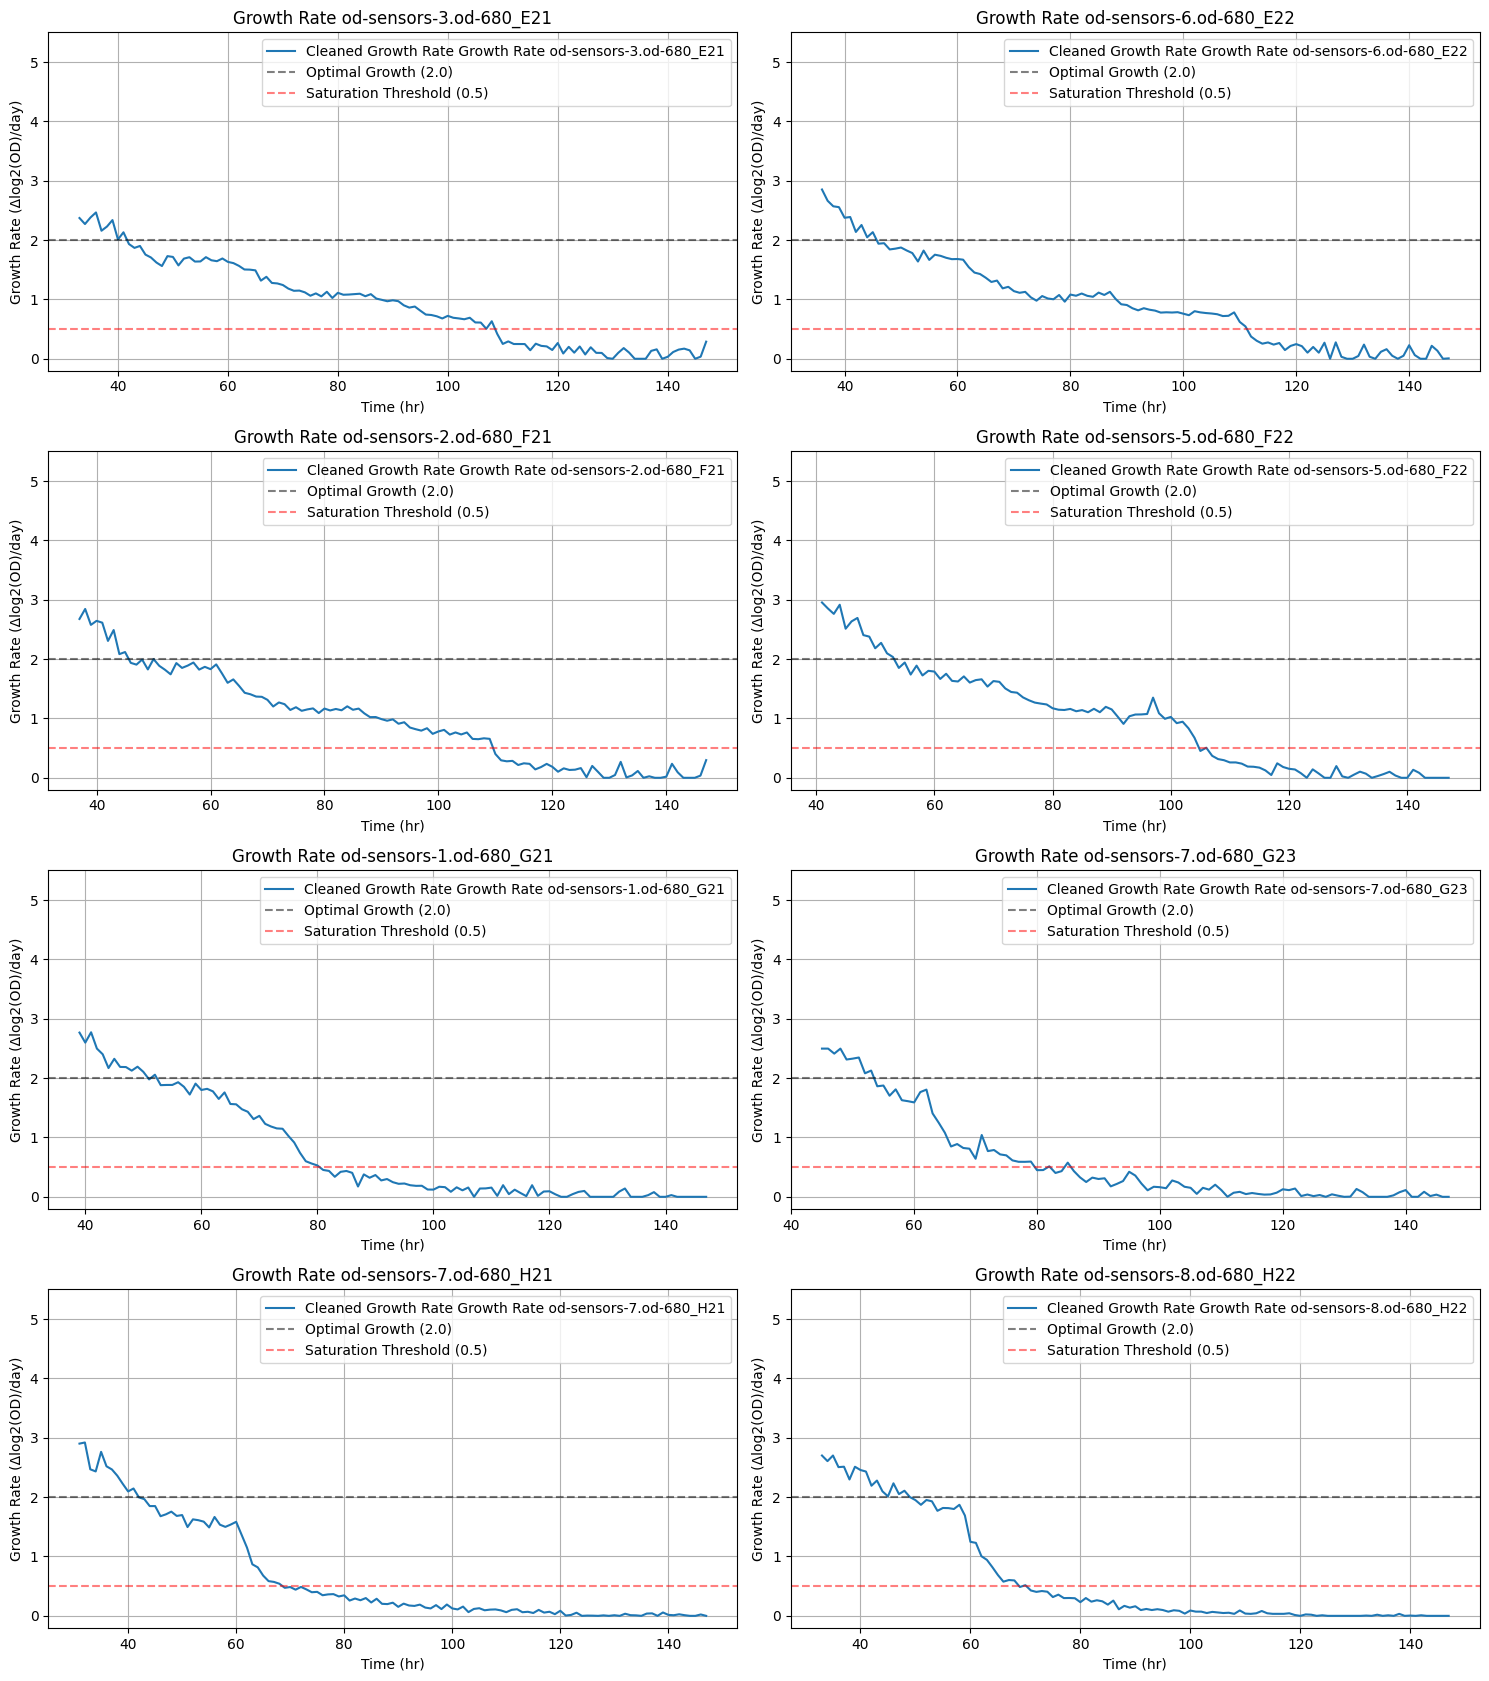

Cleaned growth rate plot saved as 'cleaned_growth_rates_plot_Urea5119.png'
Baseline growth rate data with standard error saved to 'baseline_growth_rates_se_Urea5119.csv'


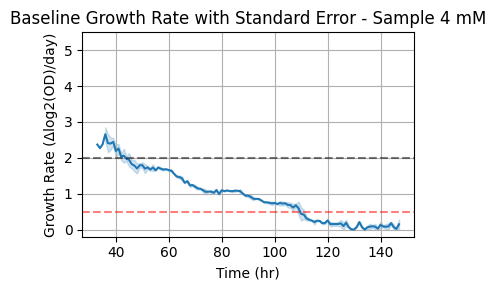

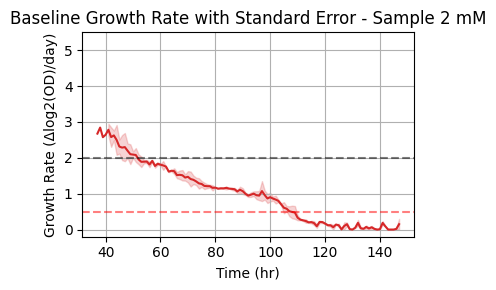

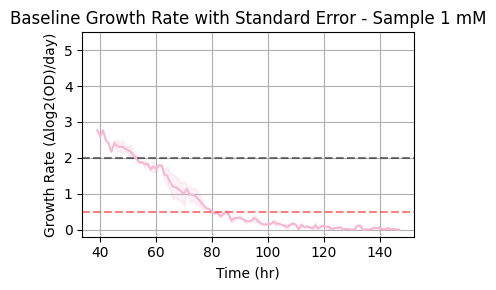

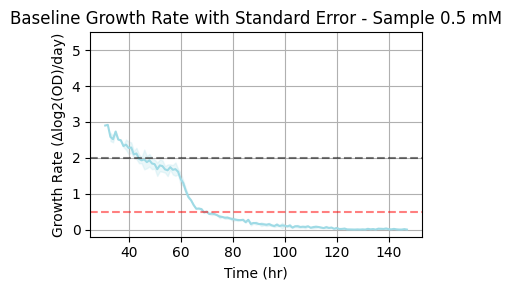

Individual growth rate SE plots saved as 'baseline_growth_rates_se_plot_[sample_type]_Urea5119.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re

# Analysis 2: Load the growth rate per Day CSV data for Plotting
processed_datafile = "Urea5119select_2025"
data = pd.read_csv('growth_rates_hourly_perDay_od_threshold_'+processed_datafile+'Urea5119select_2025''.csv')

# Clean up column names by stripping whitespace
data.columns = data.columns.str.strip()

# Identify growth rate columns
growth_columns = [col for col in data.columns if 'Growth Rate' in col]

# Step 1: Clean growth rates (remove peaks and valleys)
def clean_outliers(df, column, window_size=7, iqr_factor=1.5, max_growth_rate=5.5, min_growth_rate=0.0):
    """
    Detect outliers using IQR, cap growth rates, and replace with moving average baseline.
    Parameters:
    - df: DataFrame with growth rate data
    - column: Column name to process
    - window_size: Window size for moving average
    - iqr_factor: Multiplier for IQR to define outlier bounds
    - max_growth_rate: Maximum allowed growth rate
    - min_growth_rate: Minimum allowed growth rate
    Returns:
    - Series with outliers replaced by baseline trend
    """
    values = df[column].copy()
    # Cap growth rates
    values = values.clip(lower=min_growth_rate, upper=max_growth_rate)
    # Compute IQR, ignoring NaN
    non_nan_values = values.dropna()
    if len(non_nan_values) < 4:
        return values
    q1 = non_nan_values.quantile(0.25)
    q3 = non_nan_values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - iqr_factor * iqr
    upper_bound = q3 + iqr_factor * iqr
    # Identify outliers
    outliers = (values < lower_bound) | (values > upper_bound)
    # Compute moving average excluding outliers
    baseline = values.copy()
    baseline[outliers] = np.nan
    baseline = baseline.rolling(window=window_size, center=True, min_periods=1).mean()
    # Replace outliers with baseline values
    values[outliers] = baseline[outliers]
    return values

# Apply cleaning to each growth rate column
cleaned_data = data.copy()
for col in growth_columns:
    cleaned_data[col] = clean_outliers(data, col)
cleaned_data.to_csv('cleaned_growth_ratesPD_'+processed_datafile+'.csv', index=False)
print("Cleaned growth rate data saved to 'cleaned_growth_rates_"+processed_datafile+".csv'")

# Plot cleaned growth rates for validation
plt.figure(figsize=(15, 50))
for i, col in enumerate(growth_columns, 1):
    plt.subplot(12, 2, i)
    plt.plot(cleaned_data['Time (hr)'], cleaned_data[col], label=f'Cleaned Growth Rate {col}')
    plt.axhline(y=2.0, color='black', linestyle='--', alpha=0.5, label='Optimal Growth (2.0)')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Saturation Threshold (0.5)')
    plt.xlabel('Time (hr)')
    plt.ylabel('Growth Rate (Δlog2(OD)/day)')
    plt.title(f'{col}')
    plt.ylim(-0.2, 5.5)  # Fixed y-axis with margin
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.savefig('cleaned_growth_ratesPD_plot_'+processed_datafile+'.png')
plt.show()
print("Cleaned growth rate plot saved as 'cleaned_growth_rates_plot_"+processed_datafile+".png'")

# Step 2: Compute mean and standard error for cleaned growth rates
def extract_sample_type(column_name):
    """
    Extract sample type (A-Z) from column name.
    """
    match = re.search(r'od-sensors-\d+\.od-680_([A-Z])\d{02}', column_name)
    if match:
        return match.group(1)
    return None

# Group columns by sample type
sample_groups = {}
for col in growth_columns:
    sample_type = extract_sample_type(col)
    if sample_type:
        if sample_type not in sample_groups:
            sample_groups[sample_type] = []
        sample_groups[sample_type].append(col)

# Calculate mean and standard error for each sample type
baseline_data = []
for sample_type, cols in sample_groups.items():
    for time in cleaned_data['Time (hr)']:
        row_data = cleaned_data.loc[cleaned_data['Time (hr)'] == time, cols]
        if not row_data.empty:
            values = row_data.iloc[0]
            mean_value = values.mean()
            std_value = values.std()
            n = values.count()
            se_value = std_value / np.sqrt(n) if n > 0 else np.nan
            baseline_data.append({
                'Sample Type': sample_type,
                'Time (hr)': time,
                'Mean Growth Rate': mean_value,
                'Standard Error': se_value
            })

baseline_df = pd.DataFrame(baseline_data)
baseline_df.to_csv('baseline_growth_ratesPD_se_'+processed_datafile+'.csv', index=False)
print("Baseline growth rate data with standard error saved to 'baseline_growth_rates_se_"+processed_datafile+".csv'")

# Define the desired order and names for sample types
sample_types_ordered = ['4 mM', '2 mM', '1 mM', '0.5 mM']

# Mapping from original sample type (A-Z) to desired names
sample_type_mapping = {
    'E': '4 mM',
    'F': '2 mM',
    'G': '1 mM',
    'H': '0.5 mM'
}

# Map the 'Sample Type' column in the baseline_df dataframe to the new names
baseline_df['Sample Type'] = baseline_df['Sample Type'].map(sample_type_mapping)

# Dynamically assign colors to sample types
sample_types = sorted(sample_groups.keys())
num_samples = len(sample_types)
if num_samples <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, num_samples))
else:
    colors = plt.cm.tab20(np.linspace(0, 1, 20))
    colors = np.vstack((colors, plt.cm.tab20b(np.linspace(0, 1, num_samples - 20))))
color_map = {sample_type: mcolors.to_hex(colors[i]) for i, sample_type in enumerate(sample_types)}

# Plot mean growth rates with standard error for each sample type individually
for sample_type_original in sample_groups.keys():
    sample_type_name = sample_type_mapping.get(sample_type_original, sample_type_original) # Get the mapped name or use original if not found
    plt.figure(figsize=(4, 3))
    sample_data = baseline_df[baseline_df['Sample Type'] == sample_type_name]
    time = sample_data['Time (hr)']
    mean_gr = sample_data['Mean Growth Rate']
    se = sample_data['Standard Error']
    plt.plot(time, mean_gr, label=f'Nitrate {sample_type_name}', color=color_map.get(sample_type_original, 'black')) # Use original key for color map
    plt.fill_between(time, mean_gr - se, mean_gr + se, color=color_map.get(sample_type_original, 'black'), alpha=0.2)
    plt.axhline(y=2.0, color='black', linestyle='--', alpha=0.5, label='Optimal Growth (2.0)')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Saturation Threshold (0.5)')
    plt.xlabel('Time (hr)')
    plt.ylabel('Growth Rate (Δlog2(OD)/day)')
    plt.title(f'Baseline Growth Rate with Standard Error - Sample {sample_type_name}')
    plt.ylim(-0.2, 5.5)  # Fixed y-axis with margin
    #plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'baseline_growth_rates_se_plot_{sample_type_name.replace(" ", "_")}_'+processed_datafile+'.png') # Use cleaned name for filename
    plt.show()
print("Individual growth rate SE plots saved as 'baseline_growth_rates_se_plot_[sample_type]_"+processed_datafile+".png'")